



## 📊 About the Dataset
This dataset combines information from multiple trusted sources such as real estate listings, property databases, and government records. It includes key housing and demographic features that influence property prices.

📍 **Location Data**: Longitude & Latitude

🏠 **Property Features**: Housing median age, total rooms, bedrooms

👥 **Demographics**: Population & households

💰 **Economic Indicator**: Median income

🎯 **Target Variable**: Median house value


## Dataset Description:
**Field and Description**

- **longitude (signed numeric - float) :** Longitude value for the block in California, USA
- **latitude (numeric - float )**: Latitude value for the block in California, USA
- **housing_median_age (numeric - int ) :** Median age of the house in the block
- **total_rooms (numeric - int ) :** Count of the total number of rooms (excluding bedrooms) in all houses in the block
- **total_bedrooms (numeric - float ) :** Count of the total number of bedrooms in all houses in the block
- **population (numeric - int ) :** Count of the total number of population in the block
- **households (numeric - int ) :** Count of the total number of households in the block
- **median_income (numeric - float ) :** Median of the total household income of all the houses in the block
- **ocean_proximity (numeric - categorical ) :** Type of the landscape of the block [ Unique Values : 'NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND' ]
- **median_house_value (numeric - int ) :** Median of the household prices of all the houses in the block. This is the target variable that is to be predicted using given features outlined above



## Problem Objective:
The project aims at building a model of housing prices to predict median house values in California using the provided dataset. This model should learn from the data and be able to predict the median housing price in any district, given all the other metrics.


## Import and Setup

In [1]:
# Import the necessary libraries
import numpy as np # for calculation
import pandas as pd # for data manipulation and processing

# For data visualization
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import seaborn as sns

import sklearn as sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error


sns.set_theme(context = 'paper',style = 'whitegrid')
sns.set_palette(sns.color_palette('bright'))

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv("housing_data.csv")

In [3]:
# Display the first five rows of the data
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


## Data Exploration

In [4]:
# Check the shape and size of the data
print(f"Shape of the data: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Size of data: {df.size}")

Shape of the data: 20640 rows and 10 columns
Size of data: 206400


In [5]:
# Check for the general information about the dataset
print("General Information about the dataset")
print(df.info())

General Information about the dataset
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB
None


In [6]:
# verify missing and duplicate values
missing_values = df.isnull().sum().sort_values(ascending = False)
print(f"Number of Missing Values in each column:\n\n{missing_values}\n")
print(f"Number of Duplicate Values: {df.duplicated().sum()} Duplicate Values")

Number of Missing Values in each column:

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

Number of Duplicate Values: 0 Duplicate Values


In [7]:
# Check for the percentage of missing values in total_bedrooms column
missing_percent = missing_values['total_bedrooms'] / df.shape[0] * 100
print(f"Percentage of Missing Values in total_bedrooms: {round(missing_percent,4)}%")

Percentage of Missing Values in total_bedrooms: 1.0029%


The dataset contains 20640 rows and 10 columns, with `total_bedrooms` having  a total of 207 missing values (~1%) which will be imputed using the median since the column is right-skewed and the median is more robust to outliers than the mean.
`longitude`, `latitude`, `total_bedrooms` and `median_income` are stored as float64 datatype, `housing_median_age`, `total_rooms`, `population`, `households` and `median_house_value` are stored as `int64` datatype while `ocean_proximity` is stored as a `string` datatype (a categorical data).

In [8]:
# Check for the unique values in each column in the categorical column
df['ocean_proximity'].unique()

<ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

The Ocean_proximity column contain 5 unique categories describing a district's proximity to the coast:
- `NEAR BAY` : near a bay (e.g San Francisco Bay)
- `<1H OCEAN` : less than 1 hour drive from the ocean
- `INLAND` : located inland, away from the coast
- `NEAR OCEAN` : near the ocean
- `ISLAND` : located on an island

This distinction is important as location-based features like this often correlate strongly with `median_house_value`

### Descriptive Statistics

In [9]:
print(f"STATISTICAL SUMMMARY OF THE DATASET:")
df.describe()

STATISTICAL SUMMMARY OF THE DATASET:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Key observations:

- **`median_house_value`** ranges from $14,999 to $500,001, with a mean of ~$206,856
- **`total_rooms`, `total_bedrooms`, `population`, `households`** all have large gaps between their 75th percentile and max values, indicating right-skew and potential outliers.
- **`median_income`** ranges from 0.4999 to 15.0001 (in tens of thousands), with a mean of ~3.87.
- **`housing_median_age`** ranges from 1 to 52 years, fairly evenly spread.
- **`longitude`** and **`latitude`** confirm the data is confined to California's geographic bounds.

# Exploratory Data Analysis (EDA)


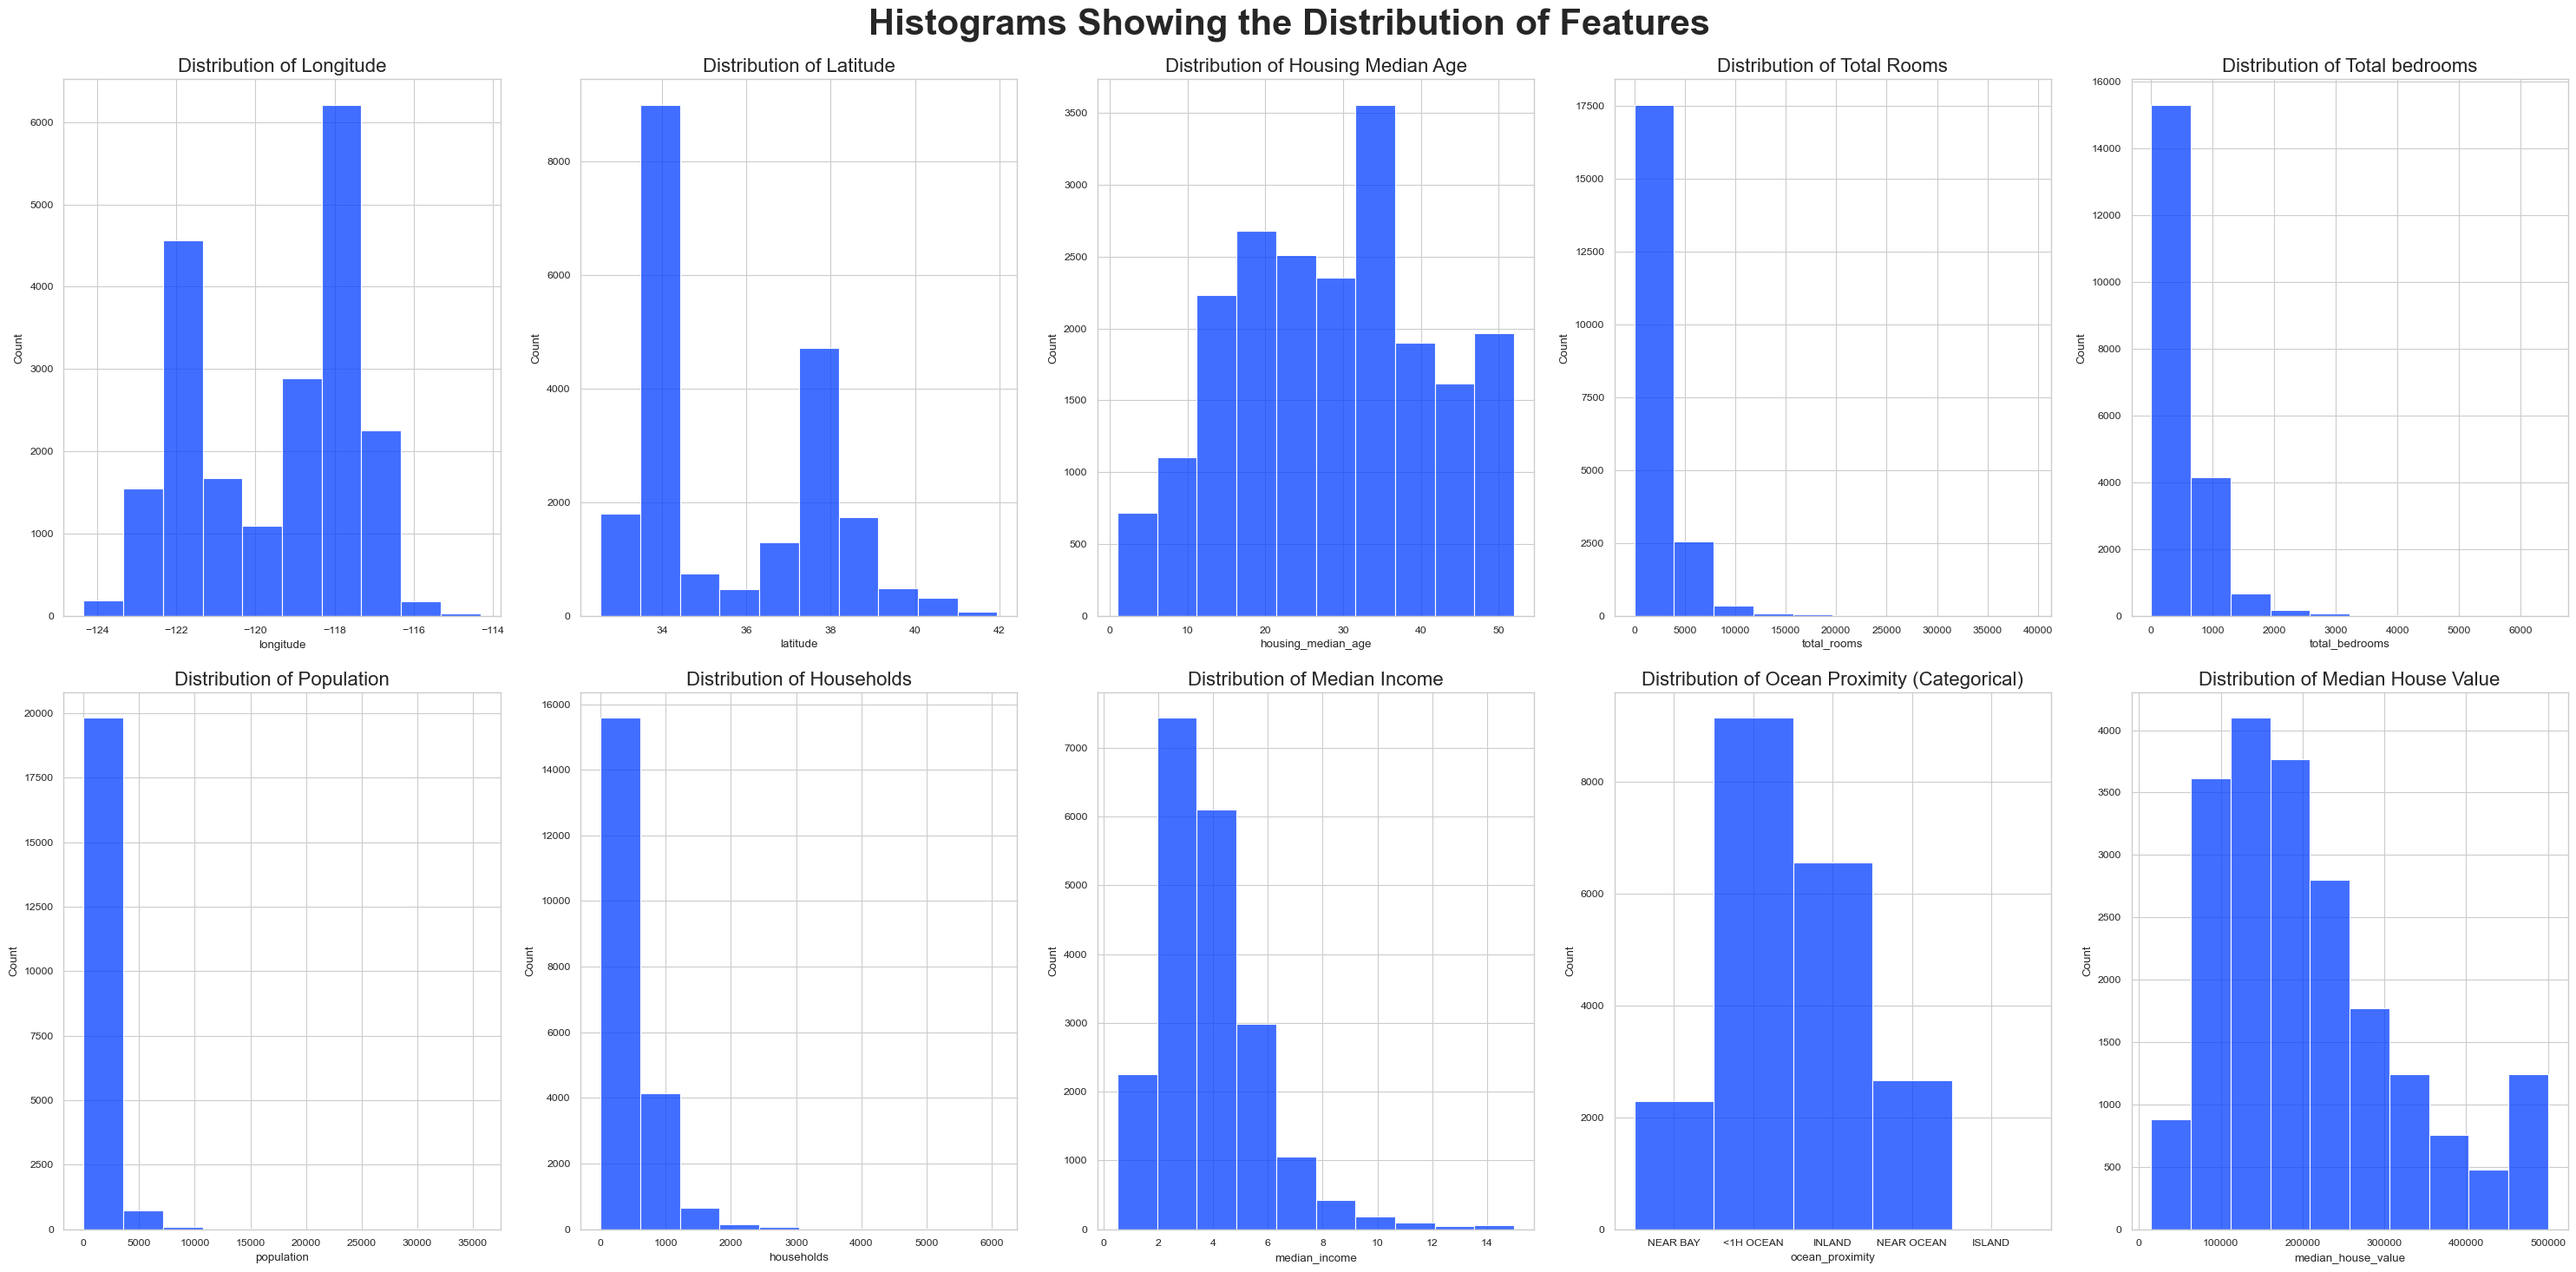

In [10]:
# Univariate analysis- to check the distribution of each feature

# Set the grid size
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize = (30,15))

axes = ax.flatten()
for i, col in enumerate(df.columns):
    sns.histplot(data = df, x =col, bins = 10, ax = axes[i])

axes[0].set_title("Distribution of Longitude", fontsize = 16)
axes[1].set_title("Distribution of Latitude", fontsize = 16)
axes[2].set_title("Distribution of Housing Median Age", fontsize = 16)
axes[3].set_title("Distribution of Total Rooms", fontsize = 16)
axes[4].set_title("Distribution of Total bedrooms", fontsize = 16)
axes[5].set_title("Distribution of Population", fontsize = 16)
axes[6].set_title("Distribution of Households", fontsize = 16)
axes[7].set_title("Distribution of Median Income", fontsize = 16)
axes[8].set_title("Distribution of Ocean Proximity (Categorical)", fontsize = 16)
axes[9].set_title("Distribution of Median House Value", fontsize = 16)


plt.rcParams['font.size'] = 16
plt.suptitle("Histograms Showing the Distribution of Features", fontsize = 30, fontweight = 'bold')

plt.tight_layout()
plt.savefig("Histogram.PNG")
plt.show()

## Key Insights from the Histogram Plot

- **Longitude** : Bimodal distribution with two peaks (around -122 and -188), reflecting two major population clusters (San Francisco Bay and Los Angeles)
- **Latitude** : Also bimodal, with peaks corresponding to the same two regions as longitude
- **housing_median_age** : Roughly uniform/slightly right-skewed with a peak around 34 and a noticeable spike at 52 - likely a capped maximum value in the data.
- **total_rooms** : heavily right-skewed with most values concentrated between 0 - 5000 rooms
- **total_bedrooms** : heavily right-skewed with most values between 0 - 1000
- **population** : heavily right_skewed with most values between 0 - 5000
- **households** : heavily right_skewed with most values between 0 - 1000
- **median_income** : right-skewed with most values concentrated  around 2-5 (in tens of thousands of dollars)
- **ocean_proximity** : Categorical; <1H OCEAN is the most frequent category, followed by INLAND
- **median_house_value** : the target variable, shows a slightly right-skewed distribution with a visible spike at the top end (~$500,000) - likely a capped maximum  value.  

Zooming into `ocean_proximity` since the categorical and histogram don't represent it well

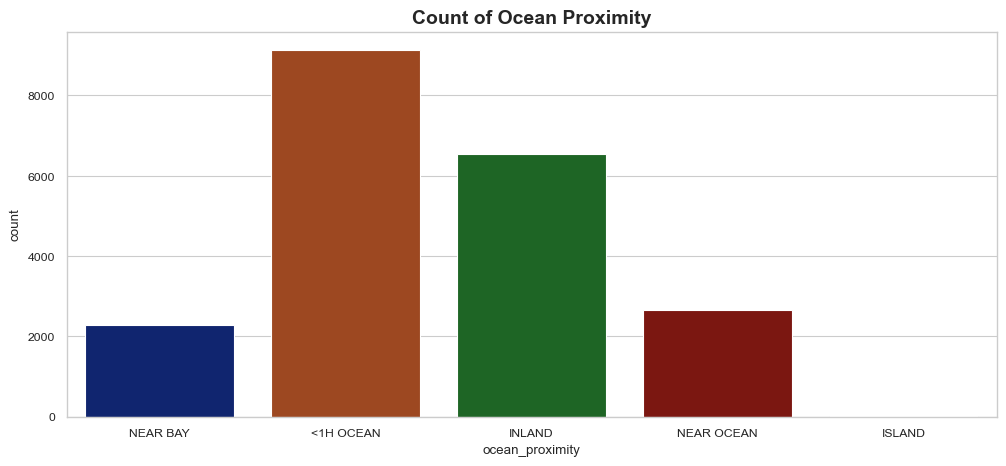

In [11]:
# plot the distribution of ocean_proximity
plt.figure(figsize=(12,5))
sns.countplot(df, x = 'ocean_proximity', orient= 'h', palette = sns.color_palette('dark',n_colors= 5))
plt.title("Count of Ocean Proximity", fontsize = 14, fontweight = 'bold')
plt.show()

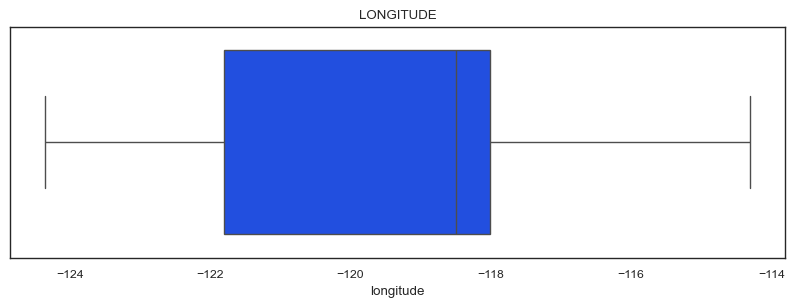

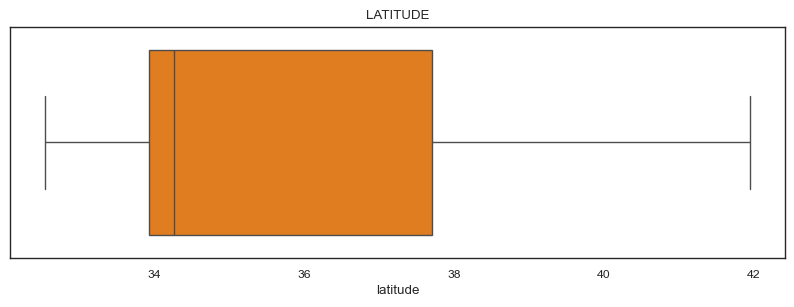

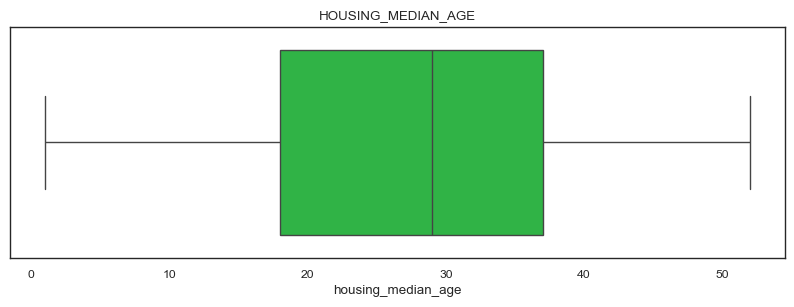

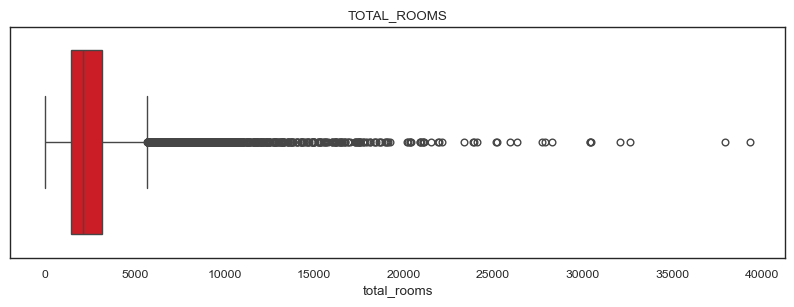

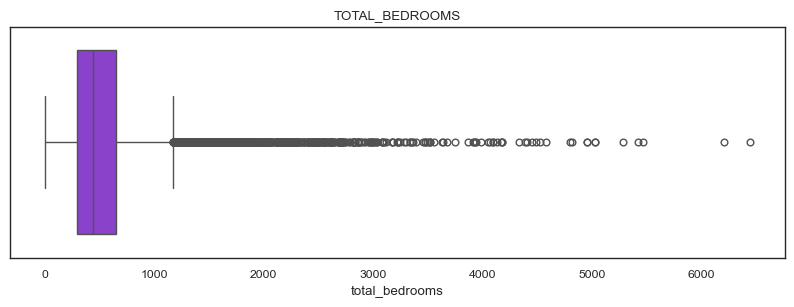

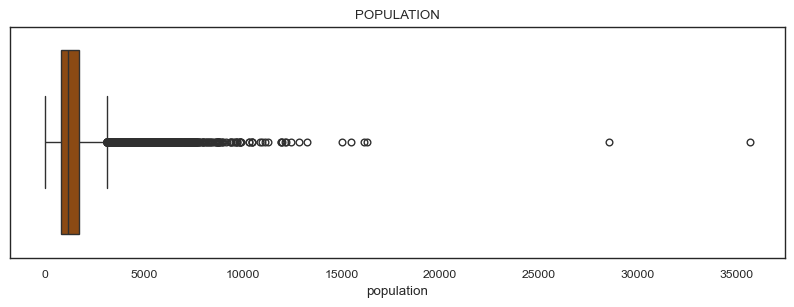

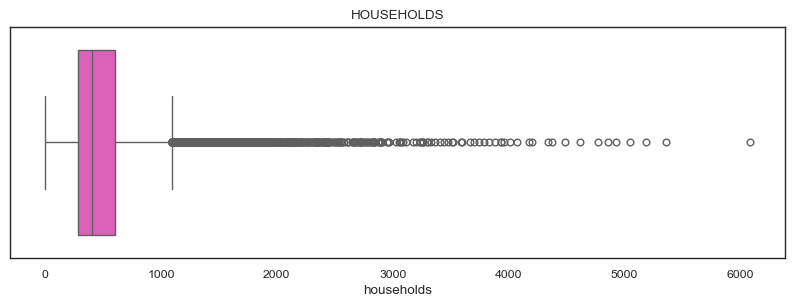

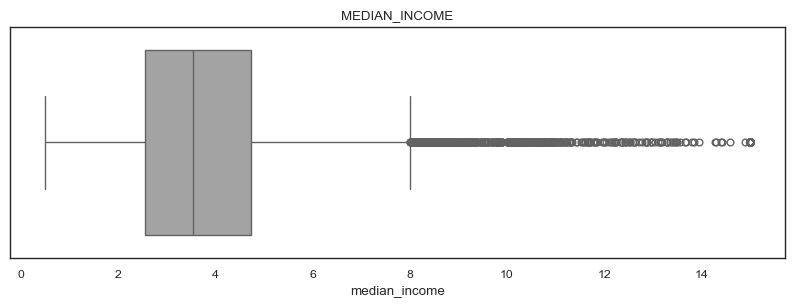

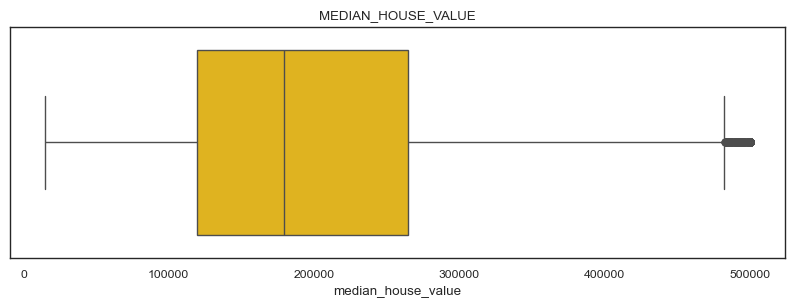

In [12]:
# Check for outliers in each columns using boxplot
color = sns.color_palette()
sns.set_style('white')
for i, col in enumerate(df.drop(columns = 'ocean_proximity').columns):
    plt.figure(figsize=(10,3))
    sns.boxplot(data = df, x = col, orientation= 'h', color = color[i])
    plt.title(f"{col}".upper())
    # print(col)

plt.show()

## Outlier Analysis  (Boxplots)

Boxplots reveal significant outliers in several features:
- **total_rooms, total_bedrooms, population, households** : All heavily right-skewed with dense outlier tails, consistent with the distributions seen in the histograms. These represent legitimately hihh-density areas rather than data errors
- **median_income** : Moderate outliers above ~$80,000 - 90,000, likely reflecting a small number of high-income districts.
- **median_house_value** : Outliers cluster tightly at the maximum value (~$500,000), confirming this is a **capped/clipped value** in the dataset rather than a natural distribution tail.
- **longitude, latitude, housing_median_age** : No significant outliers observed

Given that the outlier-heavy features (total_rooms, total_bedrooms, population, households) reflect genuine variation in housing density rather than measurement error, these outliers  will be retained. Tree-based ensemble models (Random Forest , XGboost, LightGBM) are naturally robust to this kind of skew, so no aggressive outlier removal is planned at this stage.

In [13]:
# Confirm the median_house_value cap
print((df['median_house_value'] == 500001).sum())
print((df['median_house_value'] == df['median_house_value'].max()).sum())
print(965/20640 * 100)

965
965
4.675387596899225


### Handling the Median House value Cap

965 rows (~4.7% of the dataset) have `median_house_value` capped at $500,001, matching the dataset's maximum value exactly. This is a known data collection artifact in the california Housing dataset, not a natural distribution tail - the true value for these properties is unknown.

**Decision**: These rows will be dropped before modeling, since retaining them would introduce label noise (the model cannot learn a true relationship between features and a capped/unknown target value).

In [14]:
# Impute missing total_bedrooms using group-based median
# Group by ocean_proximity since housing density/type varies by region.

df['total_bedrooms'] = df.groupby('ocean_proximity')['total_bedrooms'].transform(lambda x: x.fillna(x.median()))

# Confirm no missing values remain
print(f"Number of Missing Values Remaining: {df['total_bedrooms'].isnull().sum()}")

Number of Missing Values Remaining: 0


In [15]:
# Drop rows where median_house_value is capped at the maximum
df =  df[df['median_house_value']!= 500001].reset_index(drop = True)
print(f"Rows remaining : {df.shape[0]}")

Rows remaining : 19675


## 2D Visualizations

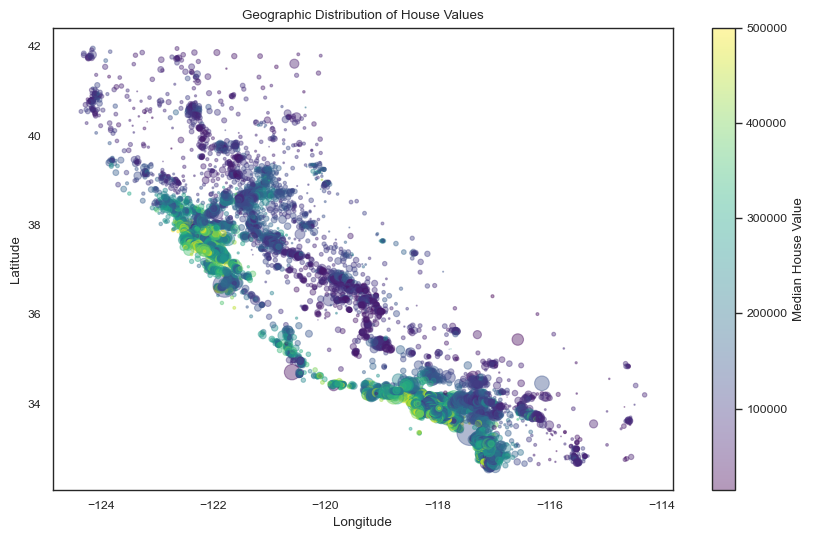

In [16]:
# Geographic  scatter plot
plt.figure(figsize = (10,6))
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],cmap = 'viridis', alpha = 0.4, s = df['population']/100)
plt.colorbar(label = 'Median House Value')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title("Geographic Distribution of House Values")
plt.savefig("Geographic_distribution.PNG")
plt.show()

### Geographic Distribution of House values
The scatter plot of longitude vs. latitude , colored by median house value, reveals a strong coastal price gradient. The highest-value propertirs cluster tightly along the coastline, particularly around the San Francisco Bay Area, while inland properties consistently show lower values regardless of population density. This confirms that location - specifically proximity to the coast  is one of the strongest visual predictors of house value in this dataset, reinforcing the importance of `latitude`, `longitude` and `ocean_proximity` as key features for modeling

## Bivariate Analysis: Features vs Target

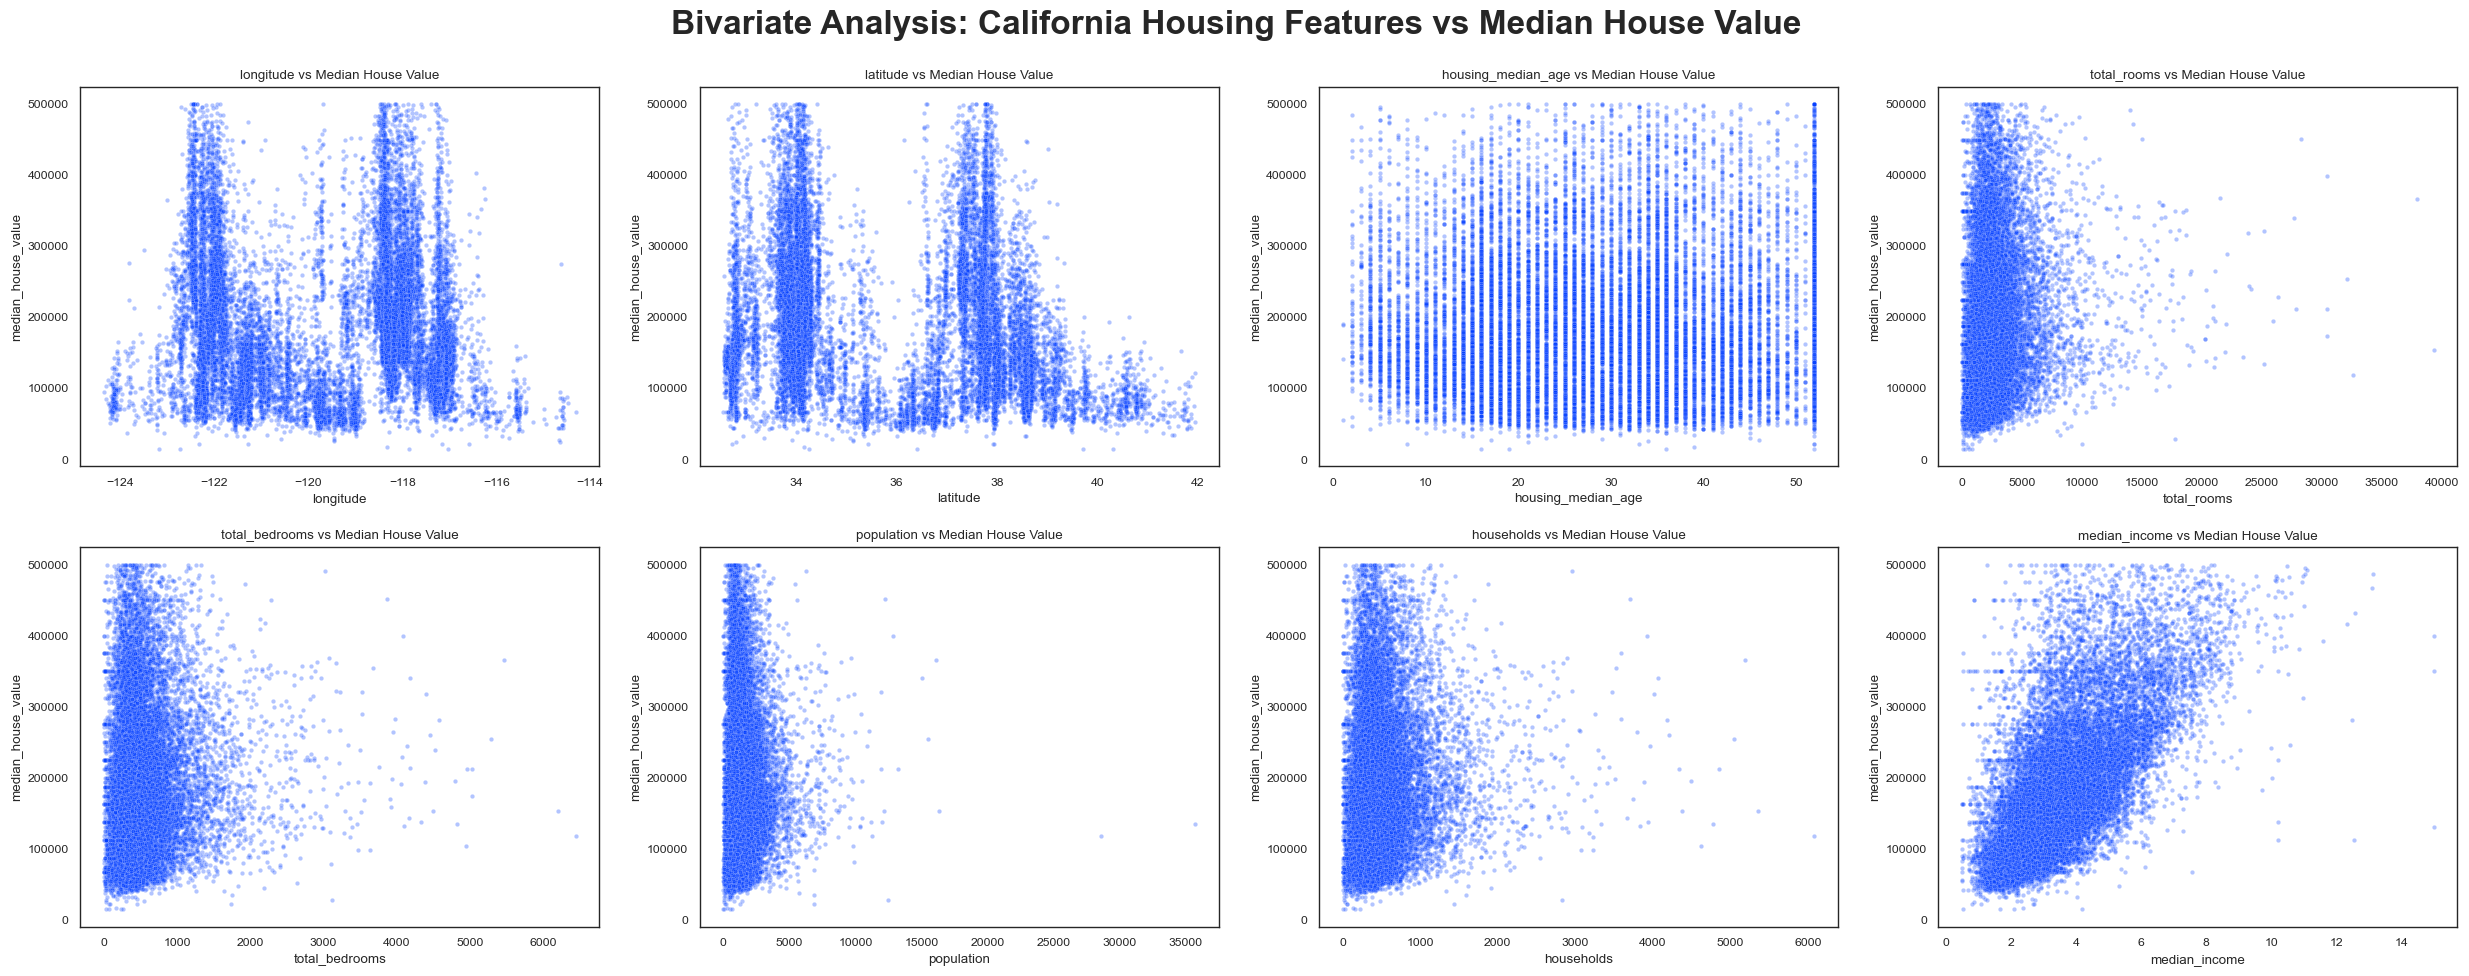

In [ ]:
# Scatter plots of each numeric feature vs the target
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize =(25,10))
axes = ax.flatten()
numeric_cols = df.drop(columns = ['median_house_value', 'ocean_proximity']).columns
for i, col in enumerate(numeric_cols):
    sns.scatterplot(data = df, x = col, y = 'median_house_value',alpha = 0.3, s = 10, ax = axes[i]).set_title(f'{col} vs Median House Value')
    plt.xlabel(col)
    plt.ylabel('median_house_value')
plt.suptitle("Bivariate Analysis: California Housing Features vs Median House Value", fontsize = 24, fontweight = 'bold')
plt.tight_layout()
plt.show()

## Key Observations:
- **Median Income** shows the strongest positive correlation with house value - a clear upward trend
- **Longiude/Latitude** show distinct vertical clusters, reflecting price differences by geographic region (e.g. coastal areas)
- **Housing Median Age, Total Rooms, Total Bedrooms, Population, Households** show no strong linear relationship - mostley scattered with a cap effect near $500,000 (likely a capped/ consored value in the dataset)
- The horizontal line at $500,000 across several plot confirms house values were capped at that maximum.

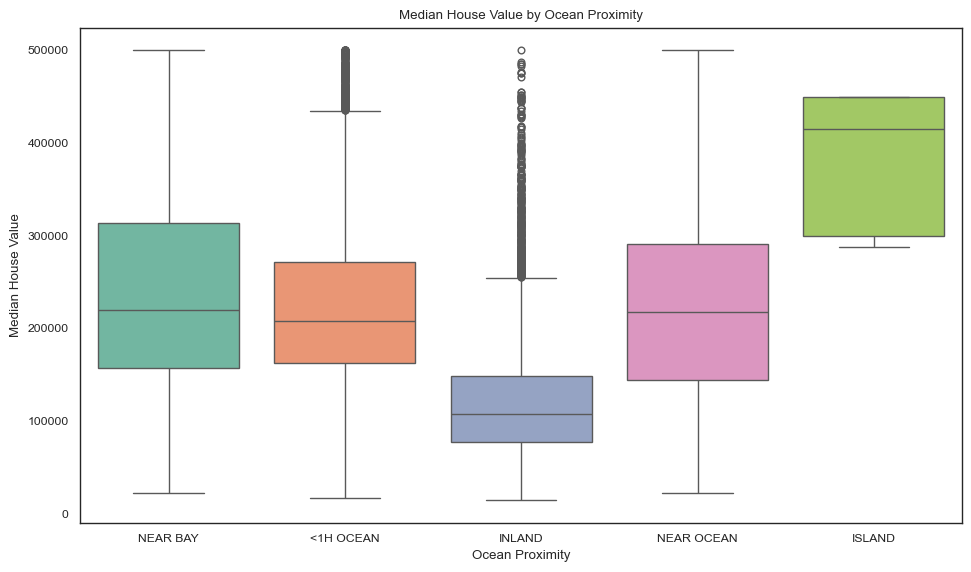

In [18]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'ocean_proximity', y = 'median_house_value', hue = 'ocean_proximity', palette='Set2', legend = False)
plt.title('Median House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.tight_layout()
plt.savefig("median_house_vs_ocean_proximity.PNG")
plt.show()

## Key Observations:
- **ISLAND** has the highest median house value, though it's based on very few samples (only ~ 5 rows), not very reliable.
- **INLAND** has the lowest median and a much tighter distribution but with a larger number of outliers.
- **NEAR BAY, <1H OCEAN, NEAR OCEAN** show similar medians and spread, all higher than INLAND.
- Confirms `ocean_proximity` is a meaningful predictor - location relative to the ocean clearly relates to house value.

### Bivariate Analysis segmented by Category

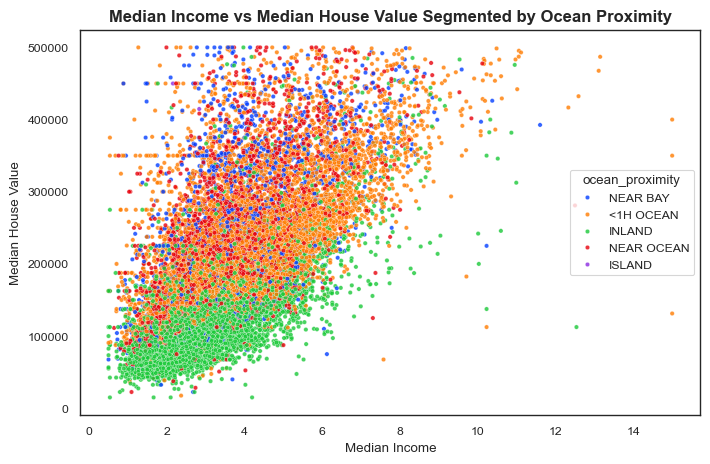

In [19]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = df['median_income'],
                y = df['median_house_value'],
                hue = 'ocean_proximity',alpha = 0.8, s = 10)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value Segmented by Ocean Proximity", fontsize = 12, fontweight = 'bold')
plt.savefig("med_inc_vs_med_house_val_by_ocean_proximity.JPEG")
plt.show()

**This scatter plot layers ocean_proximity onto the income-value relationship to see how location affects house prices at similar income levels.**

**Key insight:**
Even at the same income level, `INLAND` homes (green) consistently cluster toward lower house values, while `<1H OCEAN` and `NEAR OCEAN` homes (orange/red) skew higher. This suggests ocean_proximity carries predictive signal independent of median_income, reinforcing its value as a feature in the model.

## Correlation Heatmap

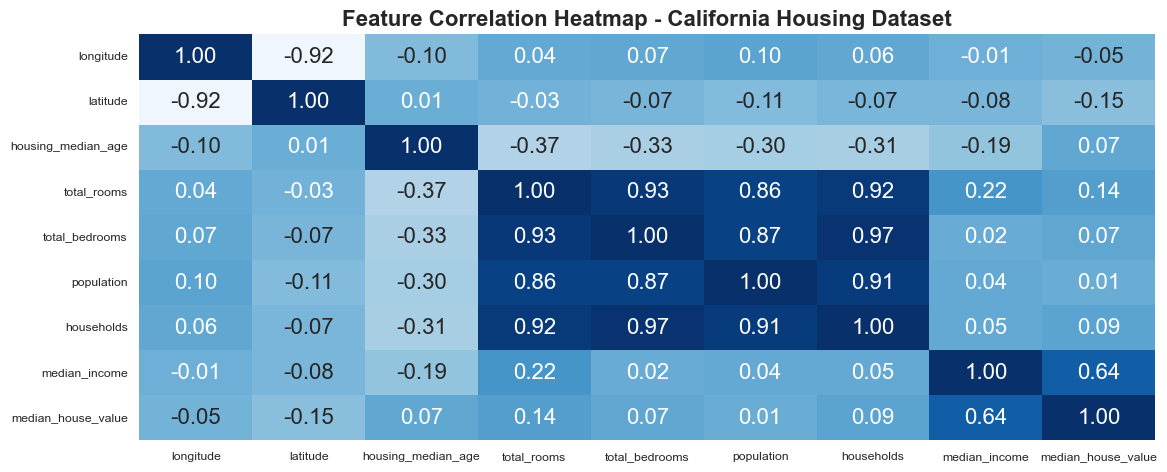

In [20]:
# visualize feature-feature and feature-target correlation analysis using heatmap
plt.figure(figsize = (12,5))
numeric_features = df.drop(columns = 'ocean_proximity')
corr = numeric_features.corr()
sns.heatmap(corr, vmin = -1, vmax = 1,cmap = 'Blues',annot = True, fmt = ".2f", cbar = False)
plt.title("Feature Correlation Heatmap - California Housing Dataset", fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig("Feature_correlation_heatmap.PNG")
plt.show()

## Insights from the Heatmap Visualization
### Feature-Feature correlation

- **`total_rooms`, `total_bedrooms`, `population`, `households`**: These columns have shown a very high level of multicolinearity which may drastically affect the performance of our model if we proceed in the machine learning modeling. New features should be engineered from the collinear columns before dropping them.

**latitude vs longitude & housing_median_age**: shows a strong negative correlation with `longitude` while showing little or no negative correlation with `housing_median_age` 

- **latitude vs total_rooms, total_bedrooms, population, households, median_income**: There is no meaningful correlation among latitude column and these features, although it has a little or weak correlation with population.

### Feature and Target correlation
The heatmap plot shows that there is no meaningful relationship between features. In terms of feature-target relationship, `median_income` is the strongest predictor of `median_house_value` having a correlation factor of `0.64`, followed by `total_rooms` showing a weak correlation with the `median_house_value` (r = 0.14) while other features shows no meaningful correlation with the target variable. `Housing_median_age` has a very weak positive correlation (0.07) with the target

### Feature Engineering

In [21]:
# Ratios that normalize the collinear columns instead of dropping them outright
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Check for inf/NaN from any zero denominators
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].isna().sum())
print(np.isinf(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']]).sum())

rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


In [22]:
# Drop the collinear columns
df = df.drop(columns = ['population', 'total_bedrooms','households'])

## Correlation Heatmap
Visualizing correlations between features (including engineered features) to identify multicolinearity and relationship with `median_house_value` before feature selection and modeling

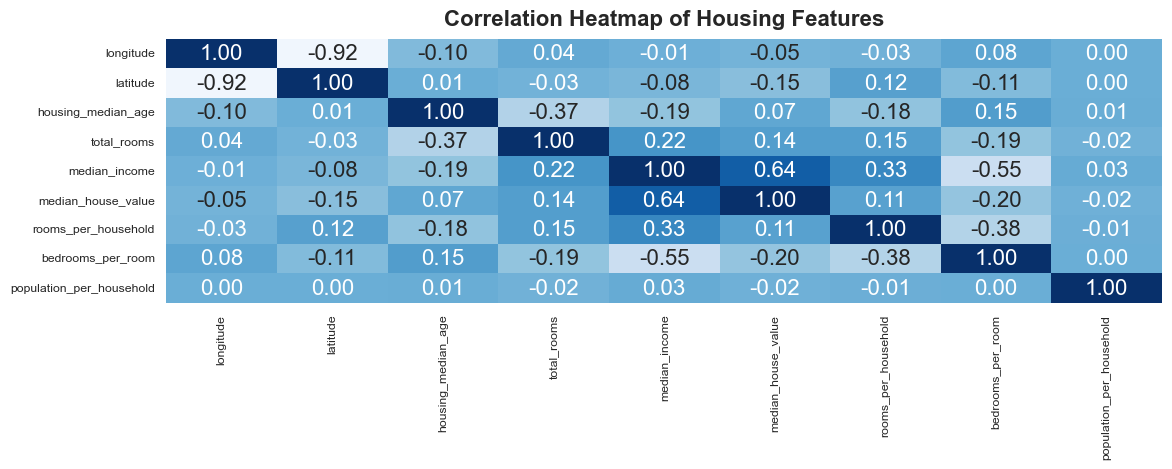

In [23]:
plt.figure(figsize = (12,5))
numeric_features = df.drop(columns = 'ocean_proximity')
corr = df.drop(columns = 'ocean_proximity').corr()
sns.heatmap(corr, vmin = -1, vmax = 1,cmap = 'Blues',annot = True, fmt = ".2f", cbar = False)
plt.title("Correlation Heatmap of Housing Features", fontsize = 16, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig("correlation_heatmap.PNG")
plt.show()

### Insights from Correlation Heatmap (After Feature Engineering)
- **bedroom_per_room** shows a strong negative correlation (-0.55) with median_house_value - a more useful signall than the raw total_rooms (0.14) or total_bedrooms alone, since it captures the ratio of housing type rather than absolute size

- **rooms_per_household (0.33)** also adds more predictive value than total_rooms did on its own confirming that per-household ratios are more informative than raw counts
 
- **population_per_household** shows very weak correlation with most features (near 0.00 across the board), suggesting it may add little value and could be a candidate to drop or investigate further for outliers

- The engineered features show moderate correlation with each other (rooms_per_household - bedrooms_per_rooms: 0.38), which is worth keeping in mind if multicolinearity becomes a concern in linear models

## Data Preprocessing

### Label Encoding

In [24]:
# Encode categorical features as a one-hot numeric array.
encoded_df = pd.get_dummies(df, columns = ['ocean_proximity'], dtype = int, drop_first=True)
# df['ocean_proximity'] = encoder.fit(df['ocean_proximity'], drop = 'first')
print("Categorical Features (ocean_proximity) Encoded Successfully.")
# Verify that the categorical features are properly encoded
encoded_df.head(5)

Categorical Features (ocean_proximity) Encoded Successfully.


,longitude,latitude,housing_median_age,total_rooms,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,8.3252,452600,6.984127,0.146591,2.555556,0,0,1,0
1,-122.22,37.86,21,7099,8.3014,358500,6.238137,0.155797,2.109842,0,0,1,0
2,-122.24,37.85,52,1467,7.2574,352100,8.288136,0.129516,2.802260,0,0,1,0
3,-122.25,37.85,52,1274,5.6431,341300,5.817352,0.184458,2.547945,0,0,1,0
4,-122.25,37.85,52,1627,3.8462,342200,6.281853,0.172096,2.181467,0,0,1,0


### Split dataset

In [25]:
# Split dataset into input and output data
X = encoded_df.drop(columns = "median_house_value") # Input data
y = encoded_df["median_house_value"] # Output data

### Train Test Split

In [26]:
# Implement the train_test_split function
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
# Verify the shape of the training and testing features
print(f"Shape of training features : {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"Shape of testing features :{ X_test.shape[0]} rows and {X_test.shape[1]} columns")

Shape of training features : 15740 rows and 12 columns
Shape of testing features :3935 rows and 12 columns


## Modeling and Evaluation

In [27]:
# initialize the machine learning algorithms for training and testing the models
models = {"Random Forest" : RandomForestRegressor(random_state=42),
"XGBregressor" : XGBRegressor(),
"LGBMregressor" : LGBMRegressor(),
}
model_list = []
metrics = []
for model_name, model in models.items():
    model.fit(X_train, y_train) # train the model using the training features
    y_predict = model.predict(X_test) # make predictions on the testing data
    # Evaluate model performance
    r2 = r2_score(y_test, y_predict)
    mae = mean_absolute_error(y_test, y_predict)
    mse = mean_squared_error(y_test, y_predict)
    rmse = root_mean_squared_error(y_test, y_predict)
    model_list.append(model_name)
    metrics.append([r2, mae, mse, rmse])

print(model_list)
print(metrics)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002759 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 11
[LightGBM] [Info] Start training from score 192191.086277
['Random Forest', 'XGBregressor', 'LGBMregressor']
[[0.7873024711275864, 30577.239796696314, 2120804043.358118, 46052.188258085174], [0.806835949420929, 29015.7578125, 1926036224.0, 43886.62890625], [0.8165512283299682, 29182.83250029167, 1829165100.175002, 42768.73975434631]]


In [28]:
# Result in dataframe
result = pd.DataFrame(dict(zip(model_list, metrics)), index = ["r2_Score", "mae", "mse", "rmse"])

In [29]:
result

,Random Forest,XGBregressor,LGBMregressor
r2_Score,7.873025e-01,8.068359e-01,8.165512e-01
mae,3.057724e+04,2.901576e+04,2.918283e+04
mse,2.120804e+09,1.926036e+09,1.829165e+09
rmse,4.605219e+04,4.388663e+04,4.276874e+04


### Baseline Model Evaluation Results

Three baseline regressors - Random Forest, XGBoost and LightGBM were trained on the engineered Carlifornia Housing dataset and evaluated on the held-out test set. No hyperparameter tuning was applied at this stage; the goal was to establish performance before optimization.

|Metric      | Random Forest | XGBoost    | LightGBM  |
|------------|---------------|------------|-----------|
|R² Score    | 0.7873        | 0.8608     | 0.8166    |
|MAE         | 30,577.24     | 29,015.76  | 29,182.83 |
|MSE         | 2.12e+09      | 1.93e+09   | 1.83e+09  |
|RMSE        | 46,852.19     | 43,886.63  | 42,786.74 |

**Observations:**
- **LightGBM emerges as the strongest baseline**, with the highest R² (0.8166) and lowest RMSE (~$42,769), meaning it explains the most variance in house prices and has the smallest typical prediction error of the three models.
- **XGboost performs close behind**, with R² of 0.8068 and RMSE of ~$43,887 - a gap of roughly $1,100 in RMSE compared to LightGBM.
- **Random Forest trails both boosting models**, with the lowest R² (0.7873) and highest RMSE (~$46,052), suggesting it captures less of the non-linear structure in the engineered features compared to gradient boosting approaches. 
- All three models now produce **stable, reproducible results**, since randomness in Random Forest's bootstrapping is controlled by the fixed random state.

**Interpretation:** with median house values in this dataset typically ranging from $15,00-500,001, an RMSE in the $42-46k range means prediction are generally within 15-20% of the true value - a reasonable baseline before any hyperparameter tuning. 

**Next step:** apply cross-validation  and hyperparameter tuning (RandomizedSearchCV) to  XGboost and LightGBM to see how much the error can be reduced beyond this baseline.

### Visualizations of Model Evaluation Results

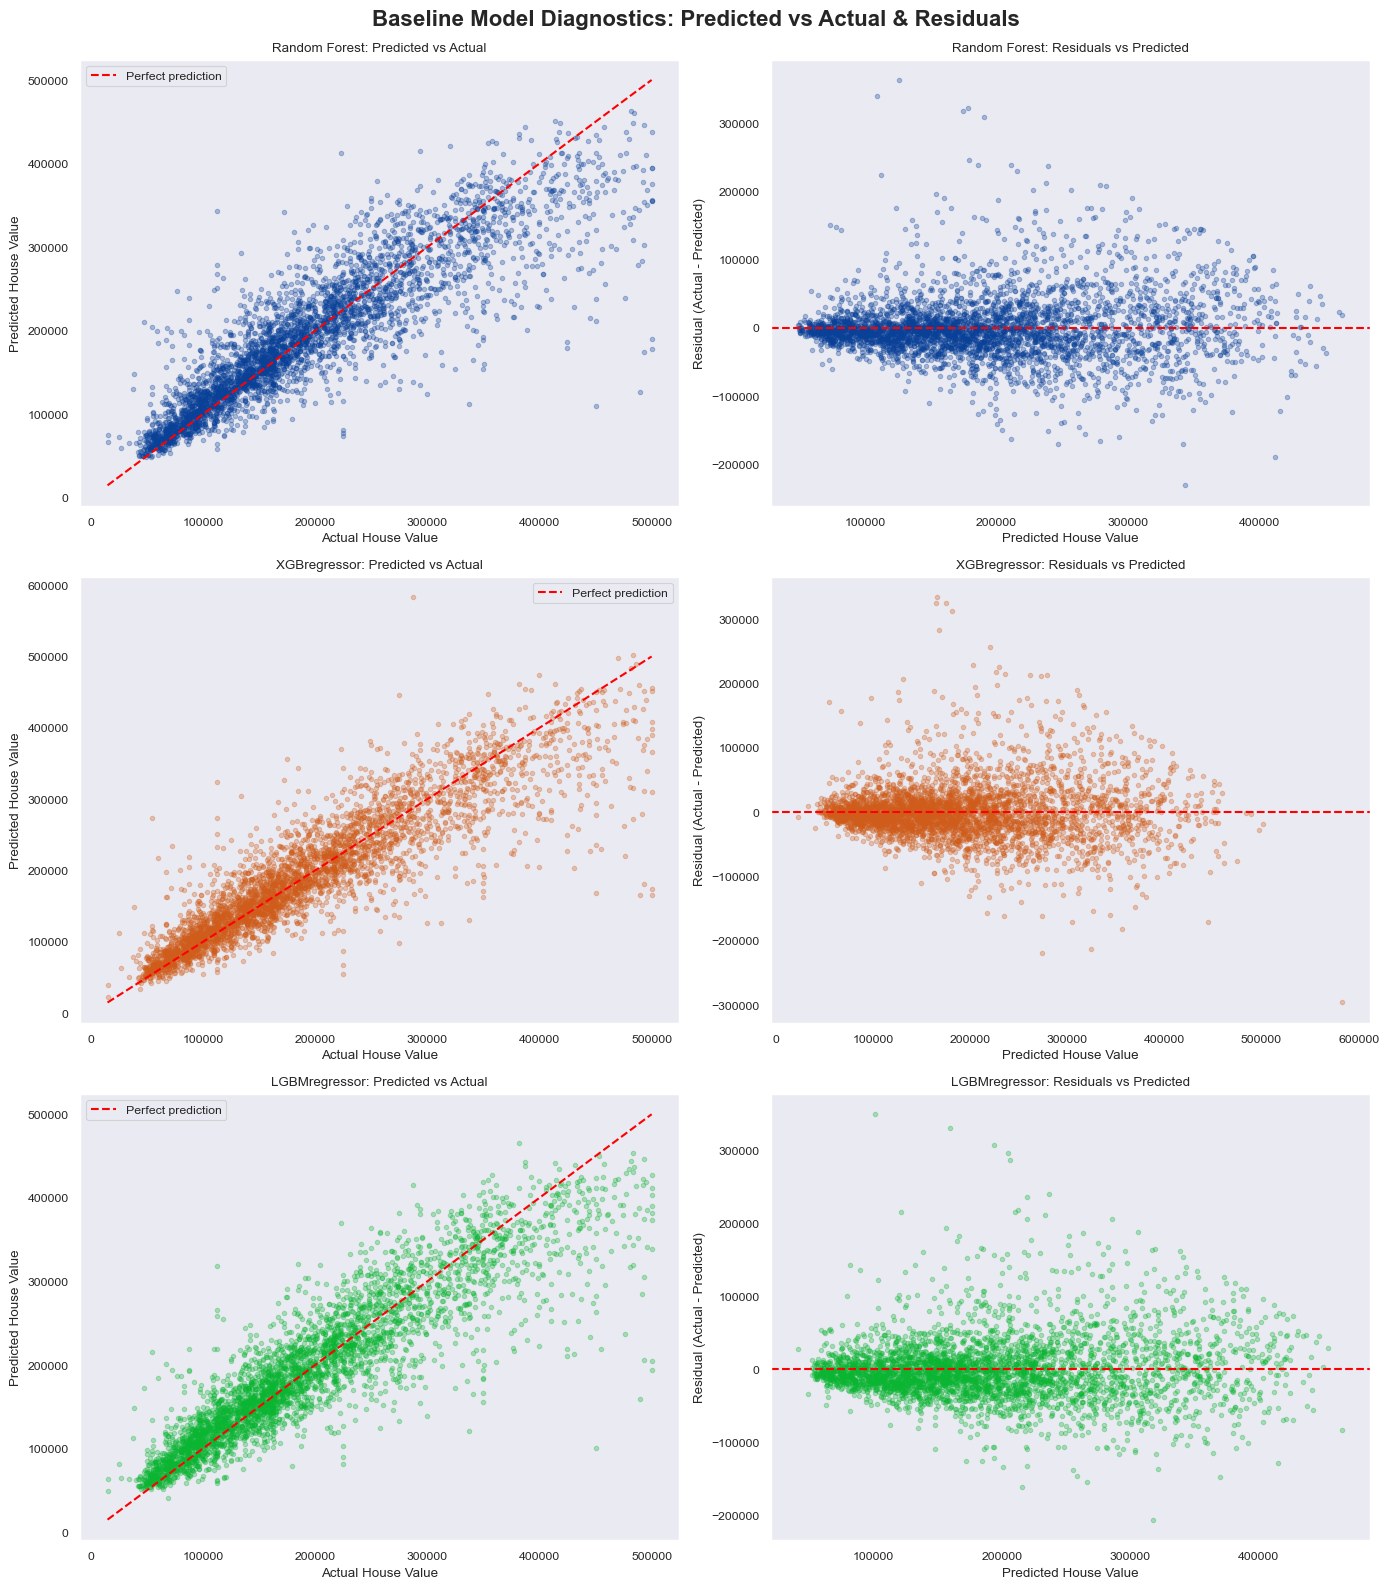

In [30]:
# Recompute predictions for each model (re-run predict so we have y_predict per model)
model_colors = {
    "Random Forest": "#094098",     # blue
    "XGBregressor" : "#CF5C1A",     # orange
    "LGBMregressor" : "#09B531",    # green
}
sns.set_theme(context  = 'paper' ,style = 'dark')
predictions = {}
for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test)

# Set up a 3x2 grid: Predicted vs Actual, and Residuals, for each model
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for i, (model_name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred

    # --- Predicted vs Actual ---
    ax1 = axes[i, 0]
    ax1.scatter(y_test, y_pred, alpha=0.3, s=10, color = model_colors[model_name])
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
    ax1.set_xlabel('Actual House Value')
    ax1.set_ylabel('Predicted House Value')
    ax1.set_title(f'{model_name}: Predicted vs Actual')
    ax1.legend()

    # --- Residuals vs Predicted ---
    ax2 = axes[i, 1]
    ax2.scatter(y_pred, residuals, alpha=0.3, s=10, color = model_colors[model_name])
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Predicted House Value')
    ax2.set_ylabel('Residual (Actual - Predicted)')
    ax2.set_title(f'{model_name}: Residuals vs Predicted')

plt.suptitle("Baseline Model Diagnostics: Predicted vs Actual & Residuals", fontsize = 16, fontweight = 'bold', y = 0.99)
plt.tight_layout()
plt.savefig("Baseline_models_comparison.JPEG")
plt.show()

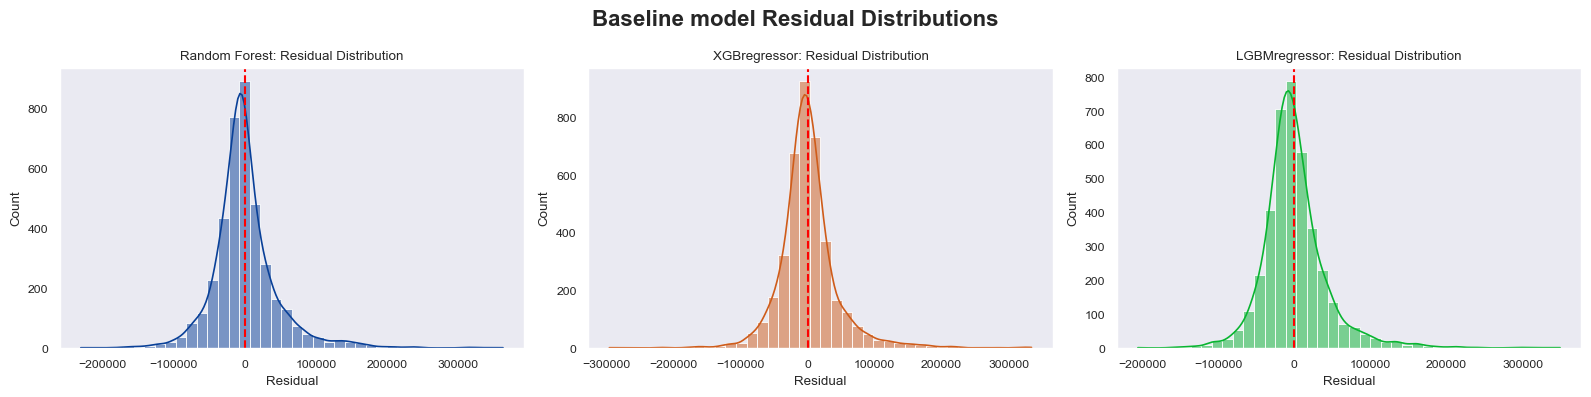

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (model_name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, ax=axes[i], bins=40, color = model_colors[model_name])
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{model_name}: Residual Distribution')
    axes[i].set_xlabel('Residual')
plt.suptitle("Baseline model Residual Distributions", fontsize = 16, fontweight = 'bold', y = 0.98)
plt.tight_layout()
plt.savefig("Residuals_comparison.JPEG")
plt.show()

## Baseline Model Diagnostics: Predicted vs Actual & Residuals

To understand where each baseline model struggles (not just by how much on average),
predicted-vs-actual scatter plots and residual plots were generated for Random Forest,
XGBoost, and LightGBM.

**Predicted vs Actual:**
All three models track the diagonal "perfect prediction" line reasonably well up to
roughly $350,000–$400,000. Beyond that point, predictions flatten out and scatter
increasingly below the diagonal, the models consistently **underpredict** the most
expensive homes. A visible cluster of points sits exactly at $500,001, which corresponds
to the dataset's known artificial cap on `median_house_value`. Since the models never see
true values above this ceiling during training, they have no way to predict beyond it.

**Residuals vs Predicted:**
The spread of residuals stays fairly consistent across most of the predicted range,
which is a good sign — it means the models aren't suffering from classic
heteroscedasticity (errors growing proportionally with price). The main irregularity is a
small number of **large positive outlier residuals**, where actual values (largely the
capped $500,001 houses) are far higher than what the model predicted.

**Residual Distributions:**
All three models produce residuals that are roughly symmetric and centered near zero,
with a slight right-skew tail — consistent with the same capped-value outliers pulling
the distribution in that direction.

**Conclusion:**
The dominant source of error is the underprediction of high-value homes, particularly those affected by the price cap, rather than a general skew across the full price range. This distinction is useful context heading into hyperparameter tuning, since it clarifies that the remaining error is concentrated in a specific, identifiable segment of the data rather than spread uniformly across all predictions.

## Cross Validation

In [32]:
# Create kfold Object
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = cross_val_score(
    XGBRegressor(random_state=42), X_train, y_train,
    cv=kfold, scoring='r2', n_jobs=-1
)
lgbm_cv_scores = cross_val_score(
    LGBMRegressor(random_state=42), X_train, y_train,
    cv=kfold, scoring='r2', n_jobs=-1
)

print(f"XGBoost CV R2: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")
print(f"LightGBM CV R2: {lgbm_cv_scores.mean():.4f} (+/- {lgbm_cv_scores.std():.4f})")

XGBoost CV R2: 0.8071 (+/- 0.0100)
LightGBM CV R2: 0.8114 (+/- 0.0081)


## Hyperparameter Optimization - RandomizedSearchCV

In [33]:
# --- XGBoost parameter grid ---
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
print(f"Best XGBoost CV R2: {xgb_search.best_score_:.4f}")

# --- LightGBM parameter grid ---
lgbm_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, -1],
    'num_leaves': [15, 31, 50, 70, 100],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42),
    param_distributions=lgbm_param_grid,
    n_iter=50,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print("Best LightGBM params:", lgbm_search.best_params_)
print(f"Best LightGBM CV R2: {lgbm_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best XGBoost CV R2: 0.8231
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 11
[LightGBM] [Info] Start training from score 192191.086277
Best LightGBM params: {'subsample': 0.9, 'num_leaves': 70, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best LightGBM CV R2: 0.8256


In [34]:
best_xgb = xgb_search.best_estimator_   # Tuned XGBoost regressor
best_lgbm = lgbm_search.best_estimator_ # Tuned Random forest regressor

tuned_results = {}

for name, model in [("XGBoost_tuned", best_xgb), ("LightGBM_tuned", best_lgbm)]:
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    tuned_results[name] = [r2, mae, mse, rmse]
    print(f"\n{name}")
    print(f"  R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

tuned_df = pd.DataFrame(tuned_results, index=["r2_Score", "mae", "mse", "rmse"])
tuned_df


XGBoost_tuned
  R2: 0.8320 | MAE: 26754.31 | RMSE: 40927.69

LightGBM_tuned
  R2: 0.8334 | MAE: 26957.01 | RMSE: 40755.00


,XGBoost_tuned,LightGBM_tuned
r2_Score,8.320050e-01,8.334197e-01
mae,2.675431e+04,2.695701e+04
mse,1.675076e+09,1.660970e+09
rmse,4.092769e+04,4.075500e+04


In [35]:
 # --- Combine baseline and tuned results into one comparison table ---

# Baseline results (rf, xgbregressor, lgbmregressor already in `result`)
# Tuned results (XGBoost_tuned, LightGBM_tuned already in `tuned_df`)

comparison_df = pd.concat([result, tuned_df], axis=1)
comparison_df = comparison_df[
    ["XGBregressor", "XGBoost_tuned", "LGBMregressor", "LightGBM_tuned"]
]

print("Full Model Comparison: Baseline vs Tuned")
comparison_df.transpose()

Full Model Comparison: Baseline vs Tuned


,r2_Score,mae,mse,rmse
XGBregressor,0.806836,29015.757812,1.926036e+09,43886.628906
XGBoost_tuned,0.832005,26754.314453,1.675076e+09,40927.690382
LGBMregressor,0.816551,29182.832500,1.829165e+09,42768.739754
LightGBM_tuned,0.833420,26957.009424,1.660970e+09,40755.001554


## Model Performance Comparison
### Visualization of Baseline vs Tuned

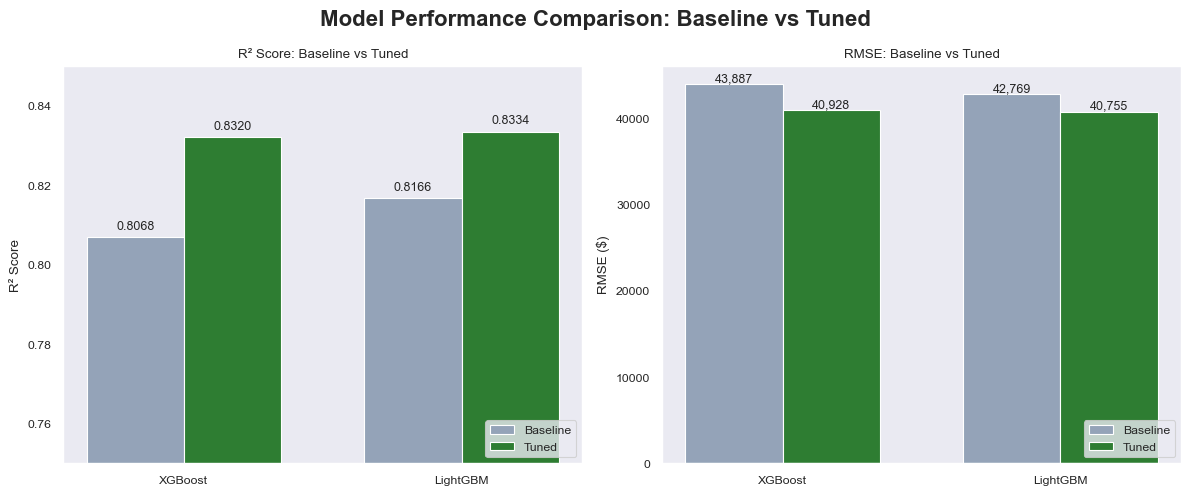

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Data: model families and their baseline/tuned scores
models = ["XGBoost", "LightGBM"]
baseline_r2 = [0.8068, 0.8166]
tuned_r2 = [0.8320, 0.8334]

baseline_rmse = [43886.63, 42768.74]
tuned_rmse = [40927.69, 40755.00]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- R2 grouped bar ---
bars1 = axes[0].bar(x - width/2, baseline_r2, width, label="Baseline", color="#94A3B8")
bars2 = axes[0].bar(x + width/2, tuned_r2, width, label="Tuned", color="#2E7D32")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("R² Score")
axes[0].set_title("R² Score: Baseline vs Tuned")
axes[0].set_ylim(0.75, 0.85)
axes[0].legend(loc ='lower right')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, height + 0.002,
            f"{height:.4f}", ha="center", fontsize=9
        )

# --- RMSE grouped bar ---
bars3 = axes[1].bar(x - width/2, baseline_rmse, width, label="Baseline", color="#94A3B8")
bars4 = axes[1].bar(x + width/2, tuned_rmse, width, label="Tuned", color="#2E7D32")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("RMSE ($)")
axes[1].set_title("RMSE: Baseline vs Tuned")
axes[1].legend(loc ='lower right')

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, height + 300,
            f"{height:,.0f}", ha="center", fontsize=9
        )

plt.suptitle("Model Performance Comparison: Baseline vs Tuned", fontsize = 16, fontweight = 'bold', y = 0.98)
plt.tight_layout()
plt.savefig("Model_performance_comparison.JPEG")
plt.show()

## Hyperparameter Tuning Results

XGBoost and LightGBM were tuned using RandomizedSearchCV (5-fold CV, `n_iter=50`,
scoring on R²) to search over key parameters including `n_estimators`, `max_depth`,
`learning_rate`, `subsample`, and model-specific parameters (`gamma` for XGBoost,
`num_leaves` for LightGBM).

| Metric   | XGBoost (baseline → tuned) | LightGBM (baseline → tuned) |
|----------|------------------------------|-------------------------------|
| R² Score | 0.8068 → **0.8320**          | 0.8166 → **0.8334**           |
| MAE      | 29,015.76 → **26,754.31**    | 29,182.83 → **26,957.01**     |
| RMSE     | 43,886.63 → **40,927.69**    | 42,768.74 → **40,755.00**     |

**Observations:**

- Both models improved meaningfully after tuning. XGBoost saw the largest gain
  (R² +0.025, RMSE down ~$2,959), narrowing the gap with LightGBM considerably.
- **LightGBM remains the top performer** post-tuning, but only marginally — the two
  models are now within 0.0014 R² and ~$173 RMSE of each other, effectively tied.
- Both tuned models now average roughly 15% error relative to the dataset's median
  house value (~$180k–200k), an improvement from ~17–19% at baseline.
- Random Forest was not retuned, as its baseline performance (RMSE ~$46,052) already
  trailed both boosting models by a clear margin, making it unlikely to close the gap
  even with tuning.

**Conclusion:** LightGBM is selected as the final model for deployment, given its
best-in-class R² and RMSE, combined with materially faster training time than
XGBoost — a practical advantage for the API serving step ahead.

## Feature Importance: XGBoost vs LightGBM (Tuned Models)


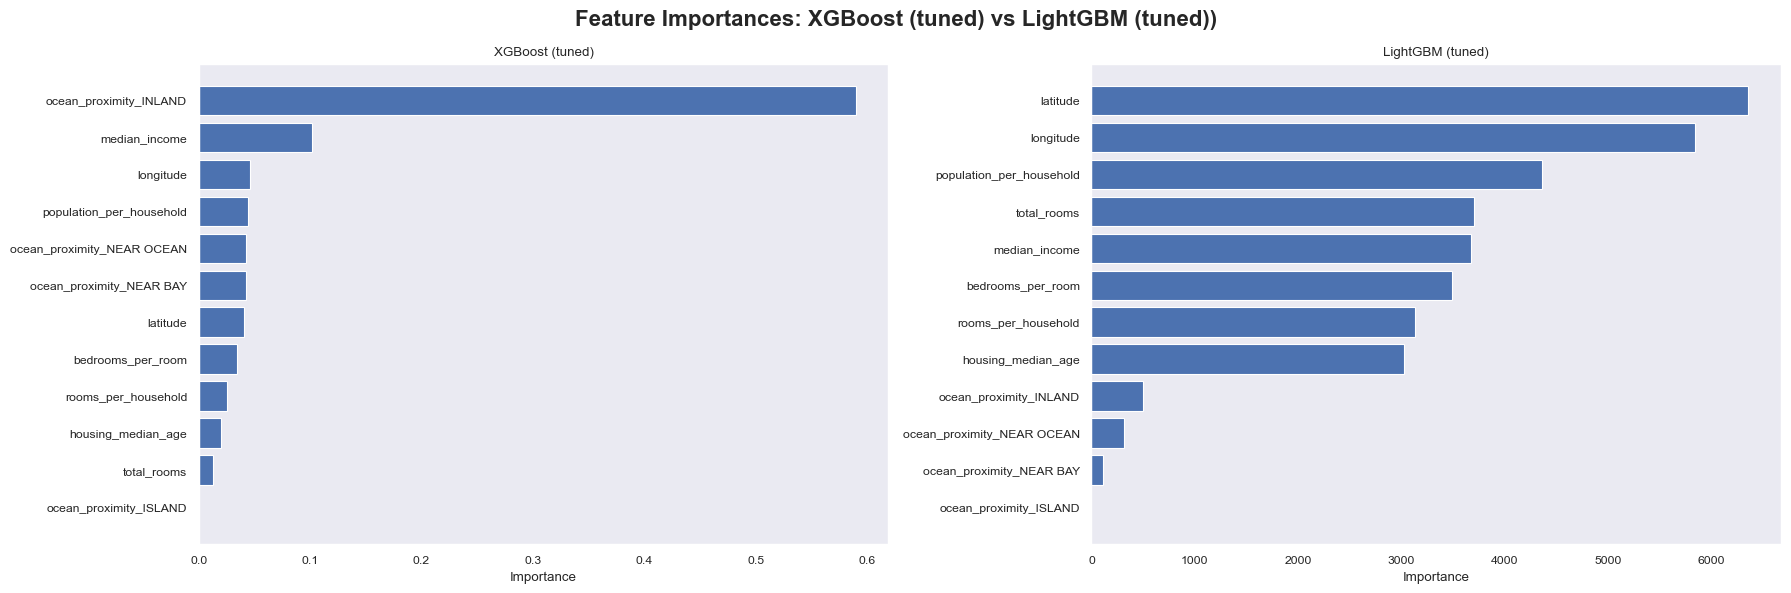

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

model_dict_final = {
    "XGBoost (tuned)": best_xgb,
    "LightGBM (tuned)": best_lgbm
}

for ax, (name, model) in zip(axes, model_dict_final.items()):
    imp_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=True)

    ax.barh(imp_df["feature"], imp_df["importance"])
    ax.set_title(name)
    ax.set_xlabel("Importance")
plt.suptitle("Feature Importances: XGBoost (tuned) vs LightGBM (tuned))", fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig("feature_importance.JPEG")
plt.show()

Feature importance was extracted from both tuned models to understand which inputs
most influence their house value predictions.

**XGBoost (tuned):**
`ocean_proximity_1` dominates the importance ranking by a wide margin, followed by
`median_income` as a distant second. All other features, including `latitude`,
`longitude`, and the engineered ratio features, contribute comparatively little.

**LightGBM (tuned):**
Importance is spread more evenly across `latitude`, `longitude`,
`population_per_household`, `total_rooms`, and `median_income`, all of which fall in a
similar range. The engineered features (`bedrooms_per_room`, `rooms_per_household`,
`population_per_household`) also register meaningfully here, unlike in the XGBoost
ranking. `ocean_proximity` categories rank near the bottom.

**Why the two models disagree:**
This difference comes down to how each library computes default feature importance.
XGBoost's default metric can behave unpredictably with one-hot encoded categorical
features, sometimes allowing a single binary column to dominate if it produces a
high-gain split early in many trees. LightGBM's default importance tends to be more
balanced and, in this case, aligns more closely with domain intuition — geographic
location and income are well-established drivers of house prices in this dataset.

**Takeaway:** feature importance rankings are algorithm-dependent and shouldn't be
taken as a single ground truth. LightGBM's ranking is treated as the more reliable
reference here, both because it matches expected real-world patterns and because it
is the model selected for deployment.

## Save Model

In [38]:
import joblib

# Save the tuned LightGBM model
joblib.dump(best_lgbm, "lgbm_housing_model.pkl")

# Save the exact column order the model expects (post one-hot encoding + engineering)
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

# Save the list of ocean_proximity categories seen during training (for one-hot consistency)
ocean_proximity_categories = ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
joblib.dump(ocean_proximity_categories, "ocean_proximity_categories.pkl")

['ocean_proximity_categories.pkl']

## Conclusion

This project developed a regression model to predict median house values in California using demographic, geographic, and housing-related features. Through exploratory data analysis, we identified `median_income` and `ocean_proximity` as the strongest predictors of house value, with income showing a clear positive correlation and location (particularly INLAND vs. coastal) creating meaningful separation in price even at similar income levels.

After engineering features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`), imputing missing values, and encoding categorical data, three models were trained and compared: Random Forest, XGBoost, and LightGBM. **LightGBM emerged as the best-performing model**, achieving an R² of **0.8334** and an RMSE of **40,755.00**, meaning it explains roughly 83% of the variance in median house values with a reasonably tight prediction error given the target's range.

**Limitations:**
- The dataset caps `median_house_value` at $500,000, meaning any home actually worth more was recorded at exactly that ceiling. This introduces a data quality artifact that can affect model accuracy at the high end.
- The `ISLAND` category under `ocean_proximity` had only ~5 samples, making any patterns observed for that group statistically unreliable.

Overall, the final LightGBM model provides a solid, deployable baseline for estimating California housing prices, and the full pipeline  from EDA through FastAPI/Streamlit deployment demonstrates an end-to-end, production-ready ML workflow.